# **Dados e Aprendizagem Automática** 

## **Decision Trees - Tratamento 3**
Nesta terceira abordagem, para além do que já tinha sido realizado no tratamento 2 fizemos uma verificação dos _outliers_ e decidimos manter os valores extremos, pois não são graves e podem conter informação revelante.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### **Preparation**
**Load the CSVs**

In [ ]:
df_train = pd.read_csv('../../Datasets/training_data.csv', encoding='latin-1')
df_test = pd.read_csv('../../Datasets/test_data.csv', encoding='latin-1')

**Missing values**

In [3]:
"""
Fill MV on target
"""
#df_train["AVERAGE_SPEED_DIFF"] = df_train["AVERAGE_SPEED_DIFF"].fillna("Low")
#df_train = df_train.dropna(subset=["AVERAGE_SPEED_DIFF"])
df_train["AVERAGE_SPEED_DIFF"] = df_train["AVERAGE_SPEED_DIFF"].fillna("None")


In [4]:
df_train['AVERAGE_CLOUDINESS'].value_counts()

AVERAGE_CLOUDINESS
céu claro            1582
céu pouco nublado     516
nuvens dispersas      459
nuvens quebrados      448
algumas nuvens        422
nuvens quebradas      416
céu limpo             153
tempo nublado          67
nublado                67
Name: count, dtype: int64

In [5]:
df_train['AVERAGE_RAIN'].value_counts()

AVERAGE_RAIN
chuva fraca                    261
chuva moderada                 153
chuva leve                      45
aguaceiros fracos               38
chuva                           30
aguaceiros                      11
chuva forte                      8
trovoada com chuva leve          7
chuvisco fraco                   5
chuva de intensidade pesado      2
chuva de intensidade pesada      1
trovoada com chuva               1
chuvisco e chuva fraca           1
Name: count, dtype: int64

In [6]:
df_train['LUMINOSITY'].value_counts()

LUMINOSITY
LIGHT        3293
DARK         3253
LOW_LIGHT     266
Name: count, dtype: int64

In [7]:
df_test['LUMINOSITY'].value_counts()

LUMINOSITY
DARK         730
LIGHT        725
LOW_LIGHT     45
Name: count, dtype: int64

In [8]:
print(df_train.isna().sum())

city_name                     0
record_date                   0
AVERAGE_SPEED_DIFF            0
AVERAGE_FREE_FLOW_SPEED       0
AVERAGE_TIME_DIFF             0
AVERAGE_FREE_FLOW_TIME        0
LUMINOSITY                    0
AVERAGE_TEMPERATURE           0
AVERAGE_ATMOSP_PRESSURE       0
AVERAGE_HUMIDITY              0
AVERAGE_WIND_SPEED            0
AVERAGE_CLOUDINESS         2682
AVERAGE_PRECIPITATION         0
AVERAGE_RAIN               6249
dtype: int64


In [9]:
df_test['AVERAGE_CLOUDINESS'].value_counts()

AVERAGE_CLOUDINESS
cï¿½u claro            345
cï¿½u pouco nublado    109
algumas nuvens          98
nuvens quebrados        96
nuvens quebradas        95
nuvens dispersas        94
cï¿½u limpo             27
tempo nublado           20
nublado                 17
Name: count, dtype: int64

**Redundant values**

In [10]:
# Clean function
def clean_categorical_text(df):

    correcoes_erros = {
        'cï¿½u': 'ceu',    
        'c\u00e9u': 'ceu', 
        'c\u00fa': 'ceu',  
        'c\u00fau': 'ceu', 
        'céu': 'ceu'
    }
    
    df['AVERAGE_CLOUDINESS'] = df['AVERAGE_CLOUDINESS'].astype(str).replace(correcoes_erros, regex=True)

    cloud_map = {
        'ceu claro': 'ceu_claro',
        'ceu limpo': 'ceu_claro',

        'ceu pouco nublado': 'pouco_nublado',
        'nuvens dispersas': 'pouco_nublado',
        'algumas nuvens': 'pouco_nublado',

        'nuvens quebrados': 'nublado', 
        'nuvens quebradas': 'nublado',
        'tempo nublado': 'nublado',
        'nublado': 'nublado',
    }
    df['AVERAGE_CLOUDINESS'] = df['AVERAGE_CLOUDINESS'].astype(str).replace(cloud_map, regex=True)
    
    df['AVERAGE_CLOUDINESS'] = df['AVERAGE_CLOUDINESS'].replace('nan', 'unknown_cloudiness')
    
    
    rain_map = {
        'chuva fraca': 'chuva_fraca',
        'chuva leve': 'chuva_fraca',
        'aguaceiros fracos': 'chuva_fraca',
        'chuvisco fraco': 'chuva_fraca',
        'chuvisco e chuva fraca': 'chuva_fraca',
        'trovoada com chuva leve': 'chuva_fraca', 

        'chuva moderada': 'chuva_moderada',
        'chuva': 'chuva_moderada',
        'aguaceiros': 'chuva_moderada',
        'trovoada com chuva': 'chuva_moderada',

        'chuva forte': 'chuva_forte',
        'chuva de intensidade pesada': 'chuva_forte',
        'chuva de intensidade pesado': 'chuva_forte'
    }
    df['AVERAGE_RAIN'] = df['AVERAGE_RAIN'].replace(rain_map)
    df['AVERAGE_RAIN'] = df['AVERAGE_RAIN'].fillna('no_rain')
    
    """ df.drop(columns = ["AVERAGE_RAIN"], inplace = True) """
    #df["LUMINOSITY"] = df_train["LUMINOSITY"].replace("LOW_LIGHT", "LIGHT")
    
    return df

In [11]:
df_train = clean_categorical_text(df_train)
df_test = clean_categorical_text(df_test)

In [12]:
df_train["LUMINOSITY"] = df_train["LUMINOSITY"].replace("LOW_LIGHT", "LIGHT")
df_test["LUMINOSITY"] = df_test["LUMINOSITY"].replace("LOW_LIGHT", "LIGHT")

In [13]:
df_test['AVERAGE_CLOUDINESS'].value_counts()

AVERAGE_CLOUDINESS
unknown_cloudiness    599
ceu_claro             372
pouco_nublado         301
nublado               228
Name: count, dtype: int64

In [14]:
""" df_test['AVERAGE_RAIN'].value_counts() """

" df_test['AVERAGE_RAIN'].value_counts() "

**Handling categoric data**

In [15]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder

In [16]:
"""
AVERAGE_RAIN
"""

le_rain = LabelEncoder()
df_train["AVERAGE_RAIN"] = le_rain.fit_transform(df_train["AVERAGE_RAIN"])
df_test["AVERAGE_RAIN"] = le_rain.transform(df_test["AVERAGE_RAIN"])


In [17]:
"""
AVERAGE_CLOUDINESS
"""
le_cloud = LabelEncoder()
df_train["AVERAGE_CLOUDINESS"] = le_cloud.fit_transform(df_train["AVERAGE_CLOUDINESS"])
df_test["AVERAGE_CLOUDINESS"] = le_cloud.transform(df_test["AVERAGE_CLOUDINESS"])


In [18]:
"""
LUMINOSITY
"""
le_lu = LabelEncoder()
df_train["LUMINOSITY"] = le_lu.fit_transform(df_train["LUMINOSITY"])
df_test["LUMINOSITY"] = le_lu.transform(df_test["LUMINOSITY"])


In [19]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6812 entries, 0 to 6811
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   city_name                6812 non-null   object 
 1   record_date              6812 non-null   object 
 2   AVERAGE_SPEED_DIFF       6812 non-null   object 
 3   AVERAGE_FREE_FLOW_SPEED  6812 non-null   float64
 4   AVERAGE_TIME_DIFF        6812 non-null   float64
 5   AVERAGE_FREE_FLOW_TIME   6812 non-null   float64
 6   LUMINOSITY               6812 non-null   int64  
 7   AVERAGE_TEMPERATURE      6812 non-null   float64
 8   AVERAGE_ATMOSP_PRESSURE  6812 non-null   float64
 9   AVERAGE_HUMIDITY         6812 non-null   float64
 10  AVERAGE_WIND_SPEED       6812 non-null   float64
 11  AVERAGE_CLOUDINESS       6812 non-null   int64  
 12  AVERAGE_PRECIPITATION    6812 non-null   float64
 13  AVERAGE_RAIN             6812 non-null   int64  
dtypes: float64(8), int64(3),

**Unique columns**

In [20]:
"""
AVERAGE_PRECIPITATION
"""
df_train.drop(columns=["AVERAGE_PRECIPITATION"],inplace=True)
df_test.drop(columns=["AVERAGE_PRECIPITATION"],inplace=True)

In [21]:
"""
city_name
"""
df_train.drop(columns=["city_name"],inplace=True)
df_test.drop(columns=["city_name"],inplace=True)

In [22]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6812 entries, 0 to 6811
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   record_date              6812 non-null   object 
 1   AVERAGE_SPEED_DIFF       6812 non-null   object 
 2   AVERAGE_FREE_FLOW_SPEED  6812 non-null   float64
 3   AVERAGE_TIME_DIFF        6812 non-null   float64
 4   AVERAGE_FREE_FLOW_TIME   6812 non-null   float64
 5   LUMINOSITY               6812 non-null   int64  
 6   AVERAGE_TEMPERATURE      6812 non-null   float64
 7   AVERAGE_ATMOSP_PRESSURE  6812 non-null   float64
 8   AVERAGE_HUMIDITY         6812 non-null   float64
 9   AVERAGE_WIND_SPEED       6812 non-null   float64
 10  AVERAGE_CLOUDINESS       6812 non-null   int64  
 11  AVERAGE_RAIN             6812 non-null   int64  
dtypes: float64(7), int64(3), object(2)
memory usage: 638.8+ KB


**Dates**

In [23]:
df_train["record_date"]

0       2019-08-29 07:00:00
1       2018-08-10 14:00:00
2       2019-09-01 16:00:00
3       2019-02-26 11:00:00
4       2019-06-06 12:00:00
               ...         
6807    2019-02-23 09:00:00
6808    2019-06-08 18:00:00
6809    2018-10-02 04:00:00
6810    2019-01-30 01:00:00
6811    2019-06-15 21:00:00
Name: record_date, Length: 6812, dtype: object

In [24]:

def extract_date_features(df):
    df['record_date'] = pd.to_datetime(df['record_date'], errors="coerce")
    df['hour'] = df['record_date'].dt.hour
    df['day_of_week'] = df['record_date'].dt.dayofweek # Monday=0, Sunday=6
    df['month'] = df['record_date'].dt.month
    
    # Create "Weekend" feature
    df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
    
    # Create "Rush Hour" feature (7 da manhã até às 9 da manhã e 4 da tarde ate às 7 da tarde, podemos brincar com estas horas)
    df['is_rush_hour'] = df['hour'].apply(lambda x: 1 if (7 <= x <= 9) or (16 <= x <= 19) else 0)
    
    return df.drop(columns=['record_date'])

df_train = extract_date_features(df_train)
df_test = extract_date_features(df_test)


In [25]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6812 entries, 0 to 6811
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   AVERAGE_SPEED_DIFF       6812 non-null   object 
 1   AVERAGE_FREE_FLOW_SPEED  6812 non-null   float64
 2   AVERAGE_TIME_DIFF        6812 non-null   float64
 3   AVERAGE_FREE_FLOW_TIME   6812 non-null   float64
 4   LUMINOSITY               6812 non-null   int64  
 5   AVERAGE_TEMPERATURE      6812 non-null   float64
 6   AVERAGE_ATMOSP_PRESSURE  6812 non-null   float64
 7   AVERAGE_HUMIDITY         6812 non-null   float64
 8   AVERAGE_WIND_SPEED       6812 non-null   float64
 9   AVERAGE_CLOUDINESS       6812 non-null   int64  
 10  AVERAGE_RAIN             6812 non-null   int64  
 11  hour                     6812 non-null   int32  
 12  day_of_week              6812 non-null   int32  
 13  month                    6812 non-null   int32  
 14  is_weekend              

**Outliers**

In [26]:
numeric_cols = df_train.select_dtypes(include=['int32','int64', 'float64']).columns


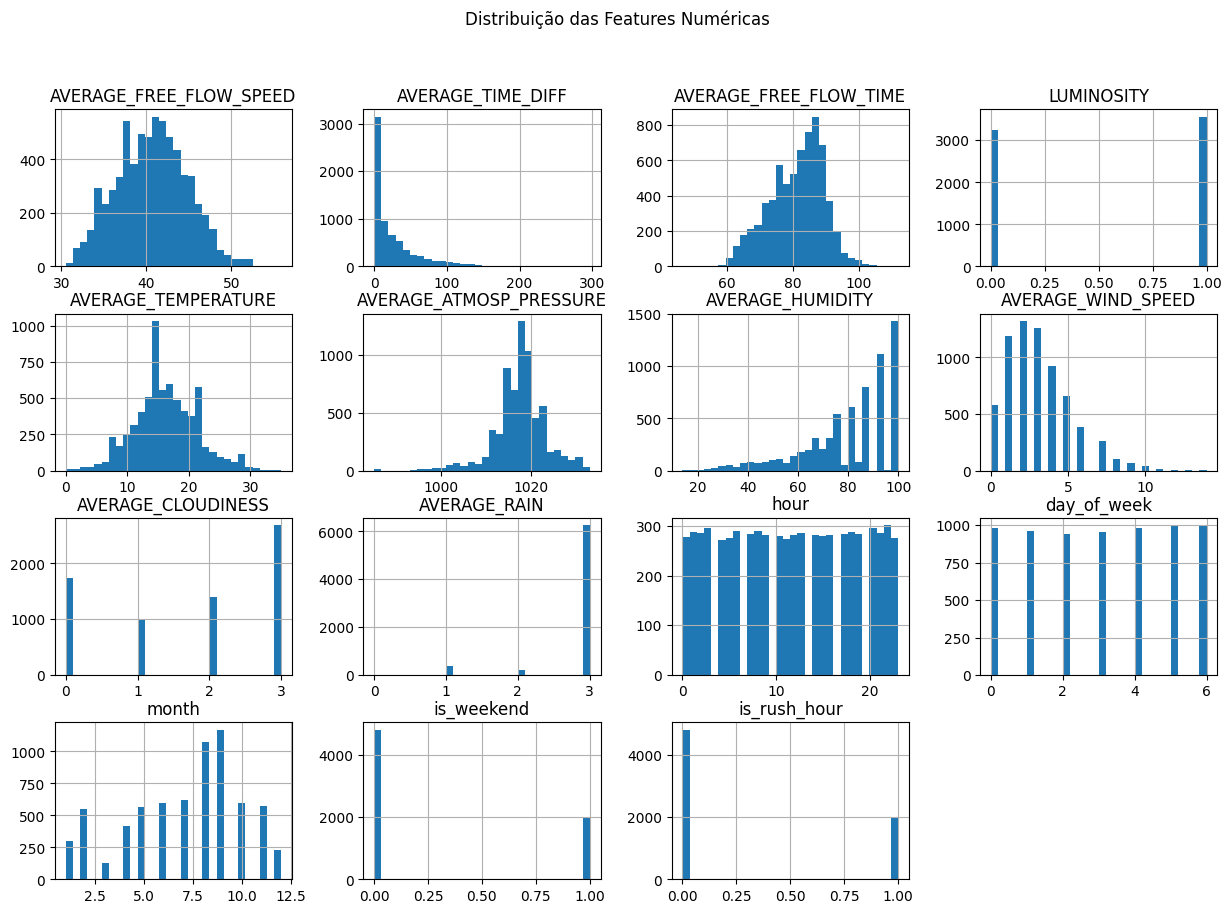

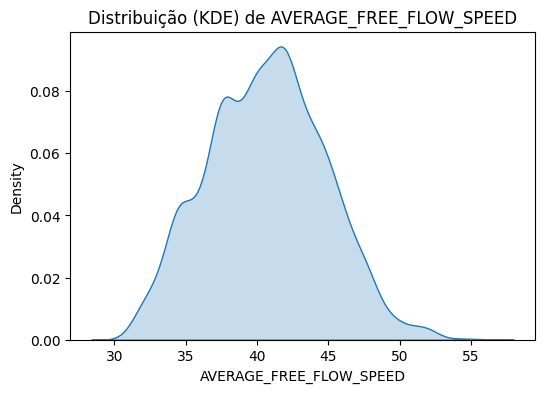

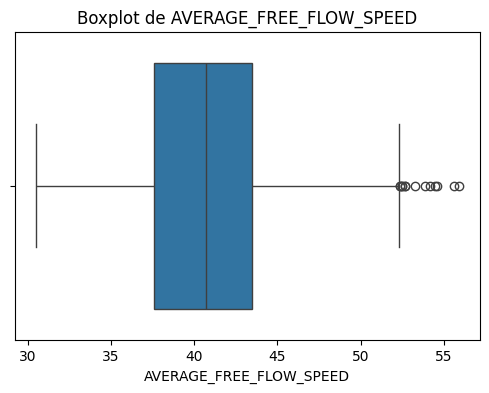

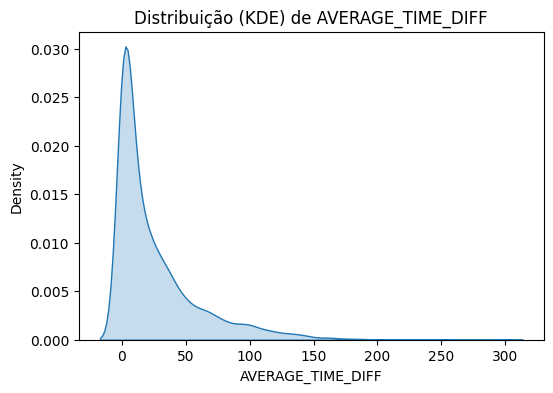

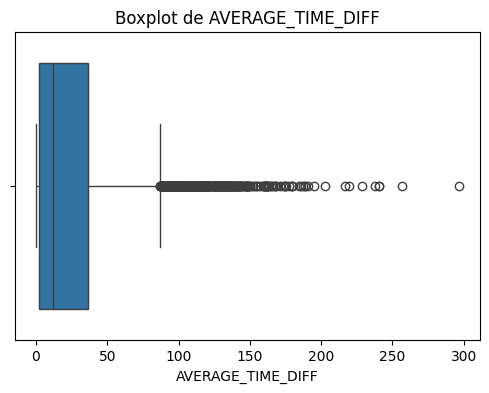

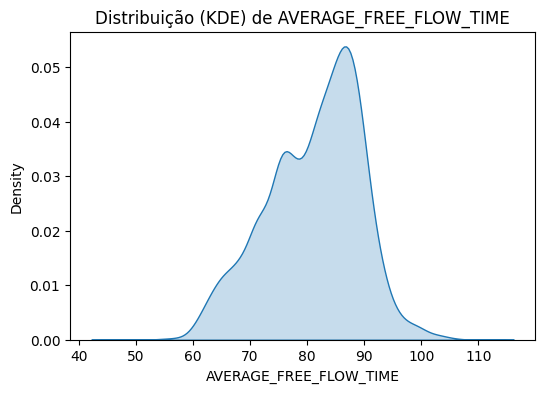

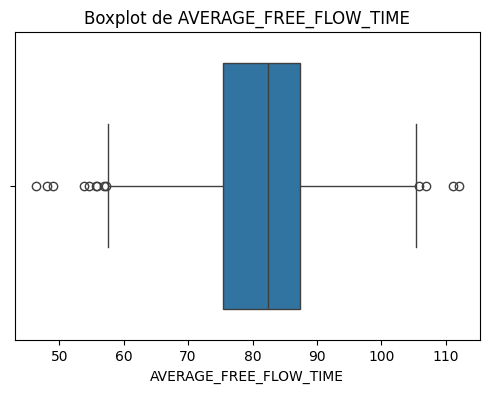

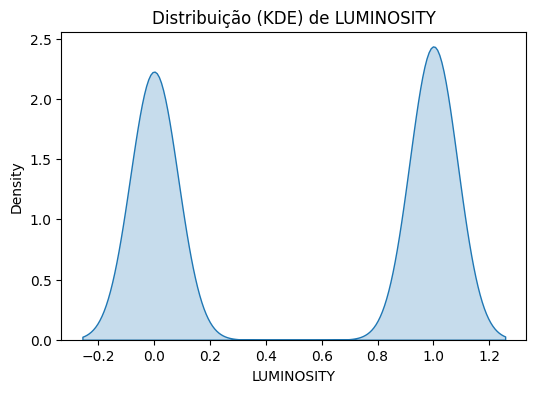

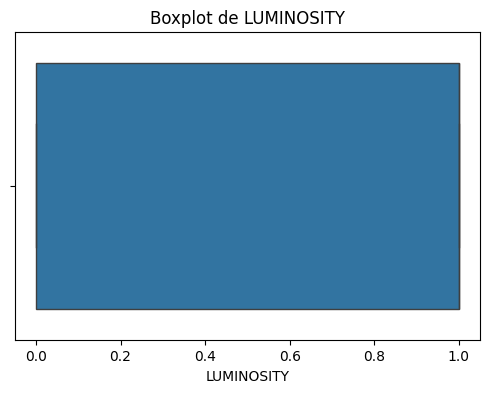

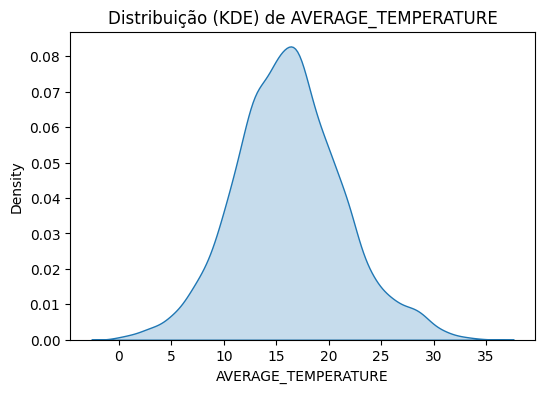

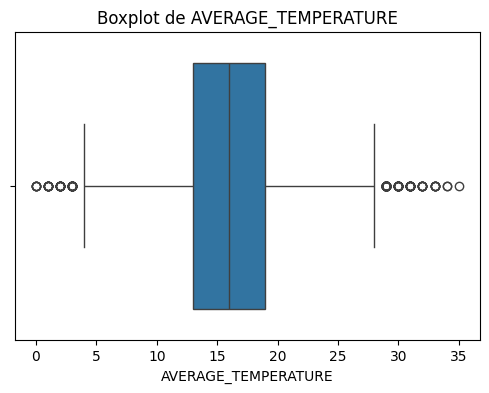

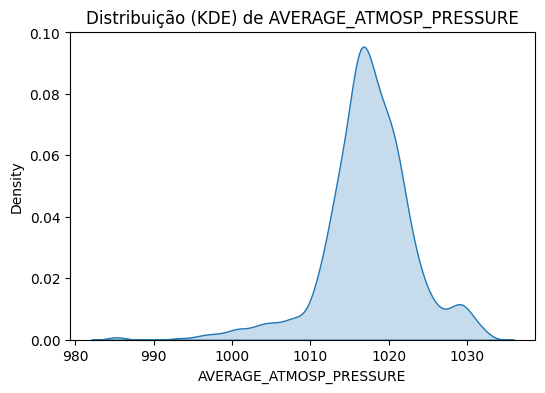

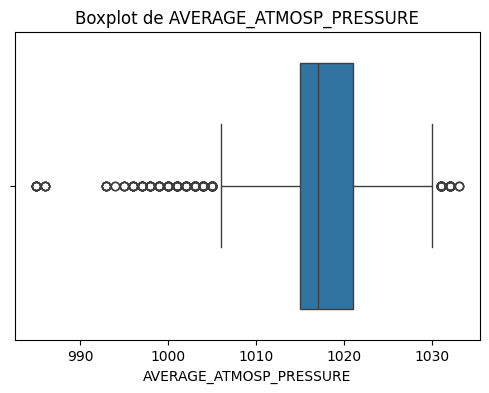

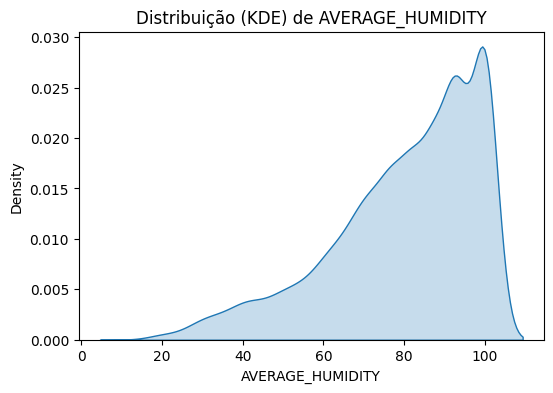

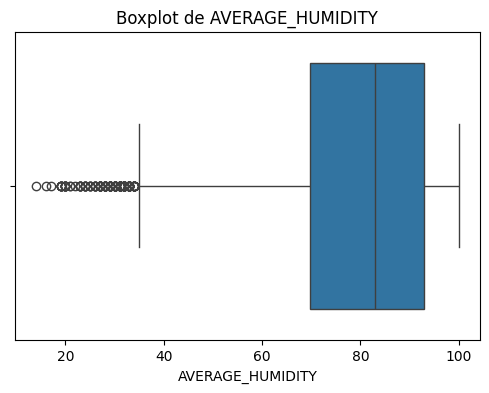

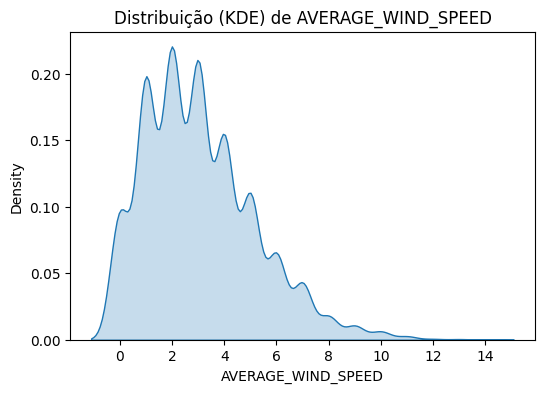

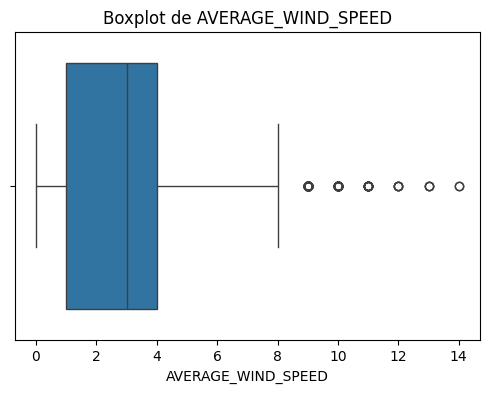

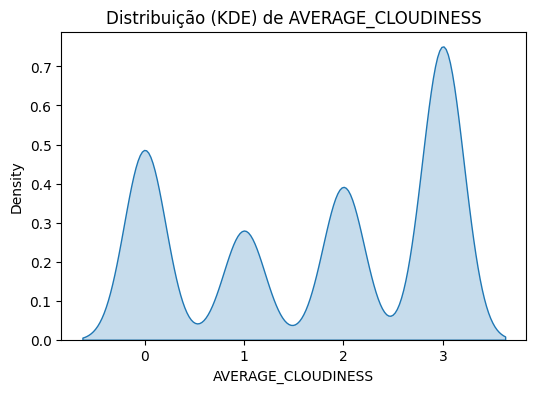

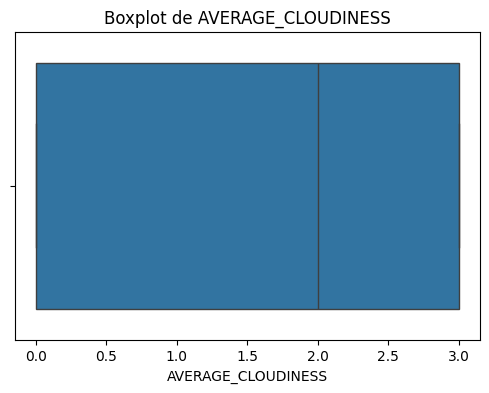

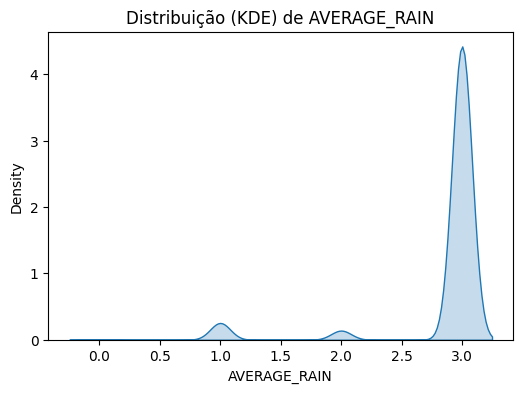

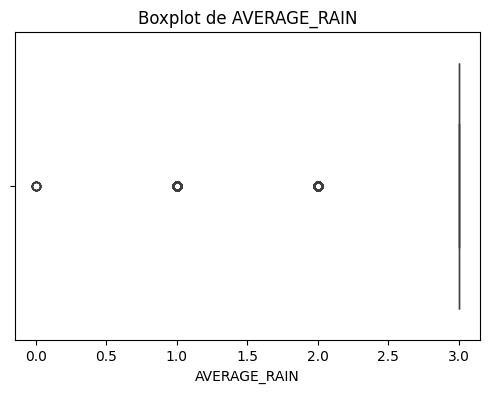

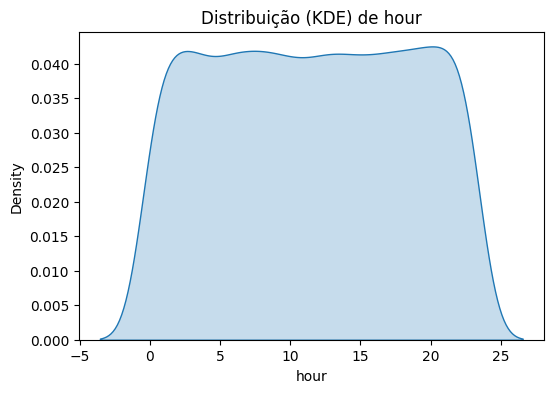

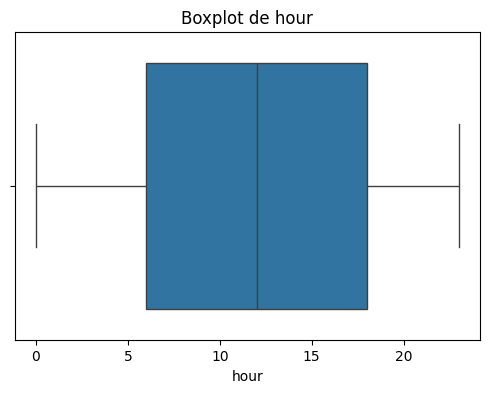

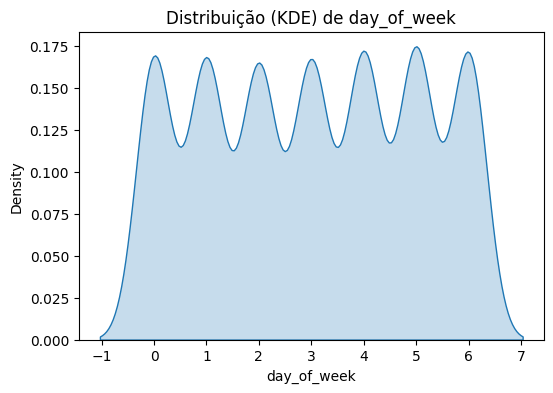

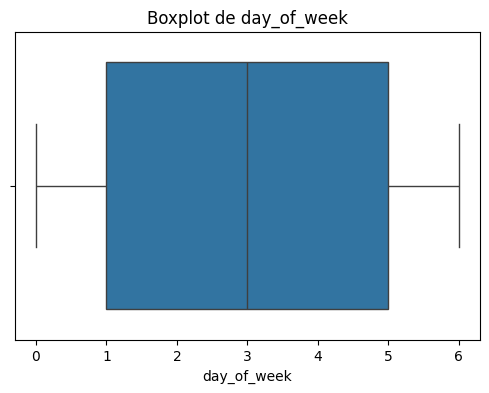

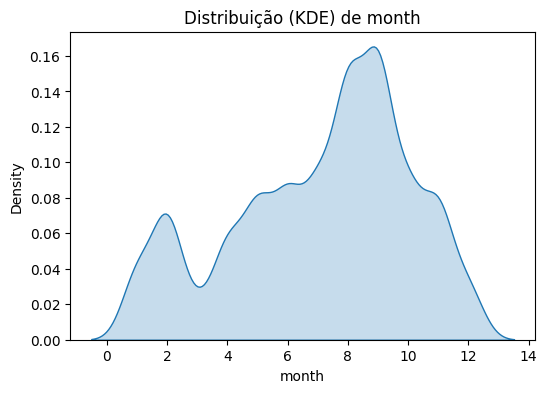

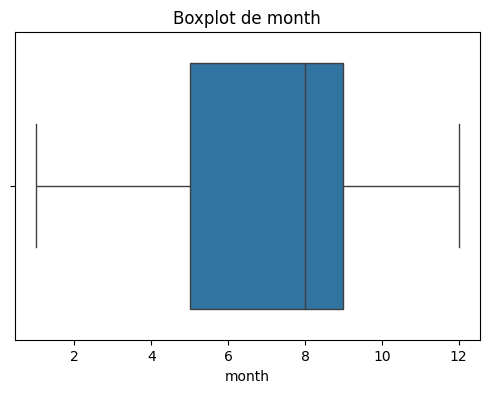

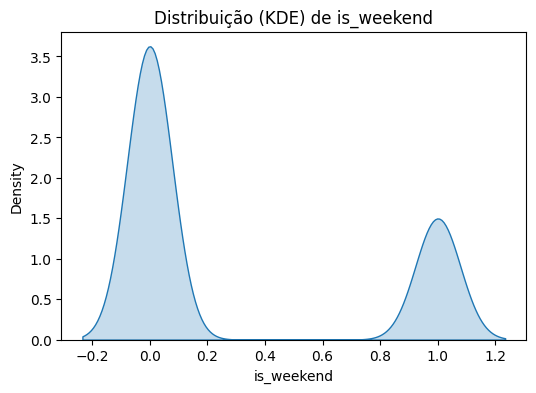

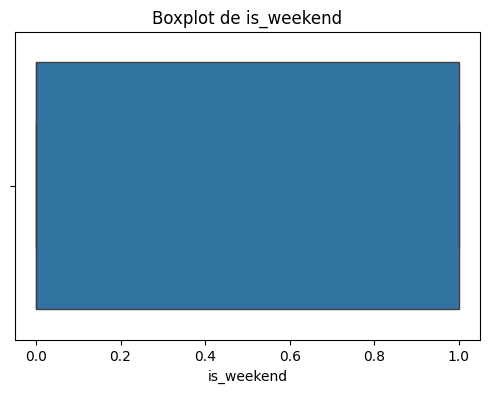

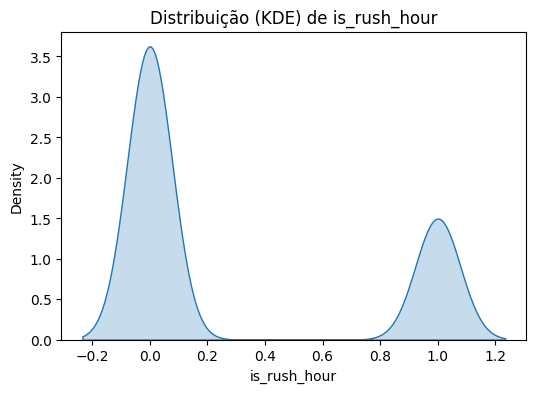

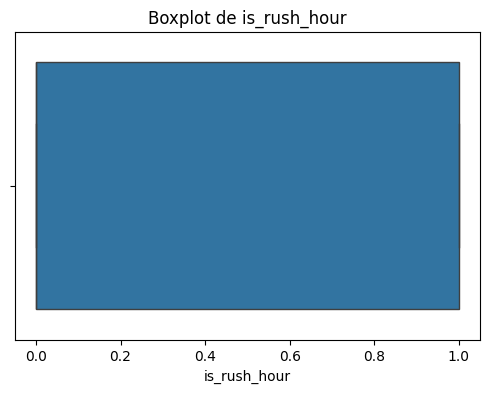

In [27]:
# Hist
df_train[numeric_cols].hist(figsize=(15, 10), bins=30)
plt.suptitle("Distribuição das Features Numéricas")
plt.show()

# KDE individual e boxplot
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.kdeplot(df_train[col], fill=True)
    plt.title(f"Distribuição (KDE) de {col}")
    plt.show()


    plt.figure(figsize=(6,4))
    sns.boxplot(x=df_train[col])
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.show()

In [28]:
df_train.describe()

,AVERAGE_FREE_FLOW_SPEED,AVERAGE_TIME_DIFF,AVERAGE_FREE_FLOW_TIME,LUMINOSITY,AVERAGE_TEMPERATURE,AVERAGE_ATMOSP_PRESSURE,AVERAGE_HUMIDITY,AVERAGE_WIND_SPEED,AVERAGE_CLOUDINESS,AVERAGE_RAIN,hour,day_of_week,month,is_weekend,is_rush_hour
count,6812.000000,6812.000000,6812.000000,6812.000000,6812.000000,6812.000000,6812.000000,6812.000000,6812.000000,6812.000000,6812.000000,6812.000000,6812.000000,6812.000000,6812.000000
mean,40.661010,25.637111,81.143952,0.522460,16.193482,1017.388139,80.084190,3.058573,1.737816,2.861715,11.534498,3.022607,7.088961,0.292278,0.292132
std,4.119023,33.510507,8.294401,0.499532,5.163492,5.751061,18.238863,2.138421,1.220857,0.483426,6.939520,2.009905,2.947594,0.454843,0.454776
min,30.500000,0.000000,46.400000,0.000000,0.000000,985.000000,14.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,37.600000,2.275000,75.400000,0.000000,13.000000,1015.000000,69.750000,1.000000,0.000000,3.000000,6.000000,1.000000,5.000000,0.000000,0.000000
50%,40.700000,12.200000,82.400000,1.000000,16.000000,1017.000000,83.000000,3.000000,2.000000,3.000000,12.000000,3.000000,8.000000,0.000000,0.000000
75%,43.500000,36.200000,87.400000,1.000000,19.000000,1021.000000,93.000000,4.000000,3.000000,3.000000,18.000000,5.000000,9.000000,1.000000,1.000000
max,55.900000,296.500000,112.000000,1.000000,35.000000,1033.000000,100.000000,14.000000,3.000000,3.000000,23.000000,6.000000,12.000000,1.000000,1.000000


Não vejo necessidade de remoção de outliers visto serem mínimos e acredito que removê-los seria perder informação relevante

**Relations**

<Axes: >

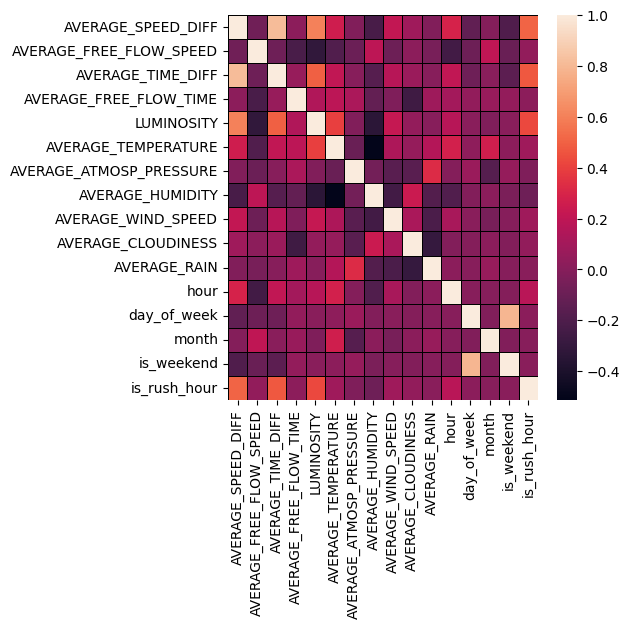

In [29]:

# Criar uma cópia apenas para análise
df_temp = df_train.copy()

""" le_speed = LabelEncoder()
df_temp["AVERAGE_SPEED_DIFF"] = le_speed.fit_transform(df_temp["AVERAGE_SPEED_DIFF"])
 """
from sklearn.preprocessing import OrdinalEncoder

ord_encoder = OrdinalEncoder(categories=[["None", "Low", "Medium", "High", "Very_High"]])

df_temp["AVERAGE_SPEED_DIFF"] = ord_encoder.fit_transform(df_temp[["AVERAGE_SPEED_DIFF"]])
df_temp["AVERAGE_SPEED_DIFF"] = df_temp["AVERAGE_SPEED_DIFF"].astype(int)

fig = plt.figure(figsize=(5,5))
corre = df_temp.corr(method='pearson')
sns.heatmap(corre,linecolor='black', linewidths=0.5)

In [30]:

target_corr = corre["AVERAGE_SPEED_DIFF"].drop("AVERAGE_SPEED_DIFF")


target_corr_sorted = target_corr.abs().sort_values(ascending=False)

print("Correlação ordenada com o target AVERAGE_SPEED_DIFF:\n")
print(target_corr_sorted)

Correlação ordenada com o target AVERAGE_SPEED_DIFF:

AVERAGE_TIME_DIFF          0.814728
LUMINOSITY                 0.598516
is_rush_hour               0.506868
hour                       0.285956
AVERAGE_TEMPERATURE        0.258776
AVERAGE_HUMIDITY           0.224832
AVERAGE_WIND_SPEED         0.209477
is_weekend                 0.197382
day_of_week                0.129614
AVERAGE_CLOUDINESS         0.086954
AVERAGE_FREE_FLOW_SPEED    0.076346
AVERAGE_FREE_FLOW_TIME     0.024276
AVERAGE_RAIN               0.018384
AVERAGE_ATMOSP_PRESSURE    0.016710
month                      0.005785
Name: AVERAGE_SPEED_DIFF, dtype: float64


As 3 primeiras parecem ser as features mais fortes para o modelo

In [31]:
corre

,AVERAGE_SPEED_DIFF,AVERAGE_FREE_FLOW_SPEED,AVERAGE_TIME_DIFF,AVERAGE_FREE_FLOW_TIME,LUMINOSITY,AVERAGE_TEMPERATURE,AVERAGE_ATMOSP_PRESSURE,AVERAGE_HUMIDITY,AVERAGE_WIND_SPEED,AVERAGE_CLOUDINESS,AVERAGE_RAIN,hour,day_of_week,month,is_weekend,is_rush_hour
AVERAGE_SPEED_DIFF,1.000000,-0.076346,0.814728,0.024276,0.598516,0.258776,-0.016710,-0.224832,0.209477,0.086954,-0.018384,0.285956,-0.129614,-0.005785,-0.197382,0.506868
AVERAGE_FREE_FLOW_SPEED,-0.076346,1.000000,-0.083653,-0.219890,-0.316753,-0.192325,-0.093648,0.191598,-0.092909,0.019937,-0.046875,-0.247337,-0.087912,0.200550,-0.101561,0.038632
AVERAGE_TIME_DIFF,0.814728,-0.083653,1.000000,0.055194,0.497565,0.205935,0.006243,-0.173598,0.169855,0.066720,0.002249,0.207378,-0.085474,0.010306,-0.151971,0.472497
AVERAGE_FREE_FLOW_TIME,0.024276,-0.219890,0.055194,1.000000,0.143592,0.190404,0.126699,-0.128376,-0.025516,-0.260960,0.080355,0.101755,0.039581,0.065347,0.044144,0.023526
LUMINOSITY,0.598516,-0.316753,0.497565,0.143592,1.000000,0.391705,-0.016425,-0.336739,0.226036,0.047214,0.003744,0.167203,0.009146,-0.023594,0.008259,0.425456
AVERAGE_TEMPERATURE,0.258776,-0.192325,0.205935,0.190404,0.391705,1.000000,-0.104469,-0.512383,0.131784,0.049820,0.156826,0.275625,0.026338,0.262218,0.019991,0.085688
AVERAGE_ATMOSP_PRESSURE,-0.016710,-0.093648,0.006243,0.126699,-0.016425,-0.104469,1.000000,-0.067071,-0.162612,-0.162098,0.321273,-0.004713,0.070422,-0.172739,0.053053,-0.023824
AVERAGE_HUMIDITY,-0.224832,0.191598,-0.173598,-0.128376,-0.336739,-0.512383,-0.067071,1.000000,-0.248708,0.242553,-0.182865,-0.191897,-0.014953,0.015225,-0.035638,-0.086514
AVERAGE_WIND_SPEED,0.209477,-0.092909,0.169855,-0.025516,0.226036,0.131784,-0.162612,-0.248708,1.000000,0.122915,-0.211451,0.118298,0.011750,-0.049090,-0.003414,0.084309
AVERAGE_CLOUDINESS,0.086954,0.019937,0.066720,-0.260960,0.047214,0.049820,-0.162098,0.242553,0.122915,1.000000,-0.295780,-0.015274,-0.009371,0.014561,-0.013218,0.041715


In [32]:
#sns.pairplot(df_temp, hue="AVERAGE_SPEED_DIFF")

Remove features with low information (principally meteorological features - low impact)

In [33]:
low_corr = corre['AVERAGE_SPEED_DIFF'].abs().sort_values()
low_corr

month                      0.005785
AVERAGE_ATMOSP_PRESSURE    0.016710
AVERAGE_RAIN               0.018384
AVERAGE_FREE_FLOW_TIME     0.024276
AVERAGE_FREE_FLOW_SPEED    0.076346
AVERAGE_CLOUDINESS         0.086954
day_of_week                0.129614
is_weekend                 0.197382
AVERAGE_WIND_SPEED         0.209477
AVERAGE_HUMIDITY           0.224832
AVERAGE_TEMPERATURE        0.258776
hour                       0.285956
is_rush_hour               0.506868
LUMINOSITY                 0.598516
AVERAGE_TIME_DIFF          0.814728
AVERAGE_SPEED_DIFF         1.000000
Name: AVERAGE_SPEED_DIFF, dtype: float64

In [34]:
def remove_weak_features(df):

    weak_features = [
        "month",
        "AVERAGE_ATMOSP_PRESSURE",
        "AVERAGE_RAIN",
        "AVERAGE_FREE_FLOW_TIME",
        "AVERAGE_FREE_FLOW_SPEED",
        "AVERAGE_CLOUDINESS"
    ]


    redundant_features = [
        "day_of_week"  
    ]

    cols_to_remove = weak_features + redundant_features

    return df.drop(columns=cols_to_remove)

df_train=remove_weak_features(df_train)
df_test=remove_weak_features(df_test)

### **Modeling**

Select features and target

In [35]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

In [36]:
X_train = df_train.drop(columns=["AVERAGE_SPEED_DIFF"])
y_train = df_train["AVERAGE_SPEED_DIFF"]

In [37]:
X_test = df_test
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

**Validation Block**

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Cópias
X_val_copy = X_train.copy()
y_val_copy = y_train.copy()

# criar conjunto de val
X_tr, X_val, y_tr, y_val = train_test_split(
    X_val_copy, y_val_copy, test_size=0.2, random_state=2022, stratify=y_val_copy
)

# Treinar modelo só para validar
clf_val = DecisionTreeClassifier(random_state=2022)
clf_val.fit(X_tr, y_tr)

# Prever na validação
val_preds = clf_val.predict(X_val)

# Mostrar accuracy
print("Validation Accuracy:", accuracy_score(y_val, val_preds))
print("\nClassification Report:\n", classification_report(y_val, val_preds))


Validation Accuracy: 0.6911225238444607

Classification Report:
               precision    recall  f1-score   support

        High       0.65      0.70      0.67       213
         Low       0.55      0.59      0.57       284
      Medium       0.65      0.63      0.64       330
        None       0.84      0.79      0.81       440
   Very_High       0.74      0.74      0.74        96

    accuracy                           0.69      1363
   macro avg       0.69      0.69      0.69      1363
weighted avg       0.70      0.69      0.69      1363



**Predict**

Predict on test set

In [39]:
clf = DecisionTreeClassifier(random_state=2022)
clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,2022
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [40]:
preds = clf.predict(X_test)

Create csv

In [ ]:
submission = pd.DataFrame({
    "RowId": range(1, len(preds)+1),
    "Speed_Diff": preds
})

submission.to_csv("../../results/DecisionTrees/dt3.csv", index=False)
submission.head()

,RowId,Speed_Diff
0,1,None
1,2,Medium
2,3,None
3,4,High
4,5,Low
